# Step-3: Diffusion Equation in 1D

## Note:


- This is the [step-3](https://nbviewer.org/github/barbagroup/CFDPython/blob/master/lessons/04_Step_3.ipynb) in [12 steps to Navier-Stokes](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/) by Prof. Lorena Barba.
- Google Gemini [conversation link](https://gemini.google.com/share/e5d2d5db4331).



## Problem Setup

### Governing Equation

$$ \frac{ \partial u}{\partial t} - \nu \frac{ \partial^2 u}{\partial x^2} = 0\ $$

where,
- $nu = 0.02$ is the diffusion coefficient (viscosity)

### Initial Condition

In this tutorial, we will use a smooth the step-wave so that our PINNs model is able to capture the wave and compute gradients reasonably. Following is the equation for the wave function:

$$ u = 1 + 0.5 \times \left[ \  tanh(k \ (x - 0.5)) - tanh(k \ (x - 1.0)) \ \right]$$

where:
- $x \in [0, 2] \ m $ is the spatial domain.
- $t \in [0, 0.5] \ s $ is the simulation duration. 



### Boundary Condition

Both the left and right boundary will be fixed to a value of $u=1 \ m/s$ for all time $t$. 


### Visualized Wave at Initial Condition**

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt 

# create u_initial
def create_u_initial(x_arr, k=25.0):
    
    step_up     = np.tanh(k * (x_arr - 0.5))
    step_down   = np.tanh(k * (x_arr - 1.0))
    u_init      = 1 + 0.5*(step_up - step_down)

    return u_init


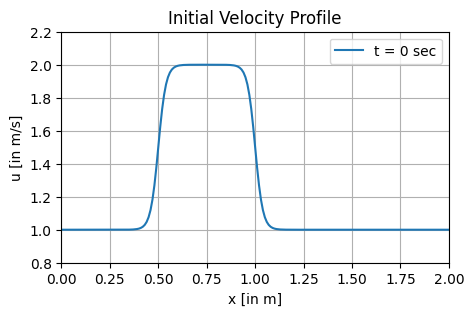

In [2]:
# simulation parameters
nu      = 0.02 # viscosity
x_max   = 2 # in m
t_end   = 0.5 # in s

nx      = 201 # number of grid points
nt      = 251 # number of time steps

dx      = x_max / (nx-1) # grid spacing [in m]
dt      = t_end / (nt-1) # time-step size [in s]

# Smooth step up at x=0.5 and smooth step down at x=1.0
k       = 25.0 # Steepness factor: higher values = sharper step, but harder to train.
x_arr   = np.linspace(0, x_max, nx) # x grid [in m]
u_init   = create_u_initial(x_arr, k) 

FIG_SIZE = (5, 3)
FIG_AXIS = [0, 2, 0.8, 2.2]
plt.figure(figsize=FIG_SIZE)
plt.plot(x_arr, u_init, label="t = 0 sec")
plt.axis(FIG_AXIS)
plt.title("Initial Velocity Profile")
plt.xlabel("x [in m]")
plt.ylabel("u [in m/s]")
plt.grid("on")
plt.legend()


## Import Libraries

In [3]:
import torch
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt  

# Set seed for reproducibility
dde.config.set_random_seed(42)  

# Nly: Set backend to PyTorch
dde.backend.backend_name = "pytorch"


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


## Select Device: CPU or GPU

### Check Availability

In [4]:
# Check if GPU is available
print("#"*17)
print("CUDA available      :", torch.cuda.is_available())
print("Default CUDA device :", torch.cuda.current_device())
print("Device name         :", torch.cuda.get_device_name(torch.cuda.current_device()))
print("#"*17)
print(f"GPU available for DeepXDE : {dde.backend.is_gpu_available()}")
print("#"*17)

# Select device for computation
device = "cuda" # must be set for both PyTroch and DeepXDE ("net" variable of DeepXDE)

# Create dummy tensor for testing
torch.set_default_device(device)
a = torch.tensor([1.0, 2.0])

# print("#"*17)
print("PyTorch tensors stored in :", a.device)  # Should show: cuda:0
print("#"*17)


#################
CUDA available      : True
Default CUDA device : 0
Device name         : NVIDIA GeForce RTX 5060 Laptop GPU
#################
GPU available for DeepXDE : True
#################
PyTorch tensors stored in : cuda:0
#################


## Implementation

The first argument to `pde` is the network input, i.e. the `x` and `y` coordinates. The second argument is the network output `u` velocity.

$$ \frac{ \partial u}{\partial t} - \nu \frac{ \partial^2 u}{\partial x^2} = 0$$

### Governing PDE

In [5]:
# PDE residual  
def pde(X, u):
    du_dt   = dde.grad.jacobian(u, X, i=0, j=1)  # i:output; j:inputs
    d2u_dx2 = dde.grad.hessian(u, X, i=0, j=0) # i:output; j:inputs
    return du_dt - nu*d2u_dx2


### Initial Condition as Hard Constraint

In this tutorial, we will create a *hard constraint* for the initial condition at $t=0$, by transforming the output of the neural network as follows:

$$ u_{pred} = u_0 + t . y_{pred} $$

In the above equation, $y_{pred} is the output of PINNs model, which we multiply with the time-step for which this prediction is made and add this to the initial value of $u$ at $t=0$. Thus for $t=0$, the value of $u_{pred} == u_0$ irrespective of the value of $y_{pred}. Our PINNs model will thus learn to predict the delta change in velocity $\Delta u$ over time $t$ instead of directly predicting the velocity $u(t)$. Note that this also means we do not need to enforce an I.C when we setup the PINNs model.


In [6]:
# Hard Constraints
# Note: 
# -> You must use your backend's math operations (e.g., tf or torch)
# -> ... because the inputs to the transform are tensors, not numpy arrays.
def output_transform(X, y_pred):
    """
    x: Network inputs. x[:, 0:1] is space, x[:, 1:2] is time.
    y: Raw network output, N(x, t).
    """
    x_space = X[:, 0:1]
    t       = X[:, 1:2]
    
    # Recreate the initial condition using Tensor operations
    u_ic = 1.0 + 0.5 * (torch.tanh(k * (x_space - 0.5)) - torch.tanh(k * (x_space - 1.0)))
    
    # Apply the constraint: u(x,t) = u_ic(x) + t * N(x,t)
    return u_ic + t*y_pred


## Create `GeometryXTime` Domain 

In [7]:
# Geometry-x-Time setup
geom        = dde.geometry.Interval(0, x_max)  
timedomain  = dde.geometry.TimeDomain(0, t_end)  
geomtime    = dde.geometry.GeometryXTime(geom, timedomain)


## Create `TimePDE` Data

Note:
- Both the left and right boundary will be fixed to a value of $u=1 \ m/s$ for all time $t$. 
- We do not have an "i.c" as the initial condition is enforced through the *hard constraint* by the neural-network output transform function.

In [8]:
# Boundary conditions (spatial boundary)
bc = dde.icbc.DirichletBC(geomtime, lambda x: 1.0, lambda _, on_boundary:on_boundary)

# Create TimePDE data  
data = dde.data.TimePDE(  
    geomtime, pde, [bc],  
    num_domain=2500,
    num_boundary=100,
    num_test=2500,
)


## Create PINNs Model

We use a fully connected neural network with `2` inputs, `3` hidden layers of `64` neurons width each, and `1` output. We also use the `apply_output_transform()` function after creating the `net` so as to enforce the *hard constraint* mentioned previously. 


In [9]:
# Neural network
# -> inputs  : x and t
# -> outputs : u
net = dde.nn.FNN([2] + [64]*3 + [1], "tanh", "Glorot normal")  

# Apply the transform to the network BEFORE creating the model
net.apply_output_transform(output_transform)

# Model
model = dde.Model(data, net)


## Training 

The PDE and the network have now been defined. Next, we build a `Model` and choose the optimizer and learning rate.

- For hyperbolic PDEs with sharp gradients (like your discontinuous initial condition), consider using `PDEPointResampler` to adaptively sample points during training.

In [10]:
# Training  
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=25_000)

# # # Optional: Continue with L-BFGS for better convergence
# model.compile("L-BFGS-B")
# losshistory, train_state = model.train()


Compiling model...
'compile' took 1.199620 s

Training model...

Step      Train loss              Test loss               Test metric
0         [1.67e+00, 6.74e-03]    [1.73e+00, 6.74e-03]    []  
1000      [1.79e-01, 1.99e-05]    [1.71e-01, 1.99e-05]    []  
2000      [3.03e-02, 1.59e-05]    [2.42e-02, 1.59e-05]    []  
3000      [1.25e-02, 3.88e-07]    [8.56e-03, 3.88e-07]    []  
4000      [7.71e-03, 9.44e-06]    [4.99e-03, 9.44e-06]    []  
5000      [4.03e-03, 4.64e-07]    [2.13e-03, 4.64e-07]    []  
6000      [2.66e-03, 3.66e-07]    [1.43e-03, 3.66e-07]    []  
7000      [1.63e-03, 4.77e-08]    [8.03e-04, 4.77e-08]    []  
8000      [2.54e-03, 5.70e-08]    [2.00e-03, 5.70e-08]    []  
9000      [8.95e-04, 1.77e-08]    [4.64e-04, 1.77e-08]    []  
10000     [7.12e-04, 2.46e-08]    [3.81e-04, 2.46e-08]    []  
11000     [7.10e-04, 1.31e-06]    [4.68e-04, 1.31e-06]    []  
12000     [1.38e-02, 5.78e-08]    [1.49e-02, 5.78e-08]    []  
13000     [4.14e-04, 2.74e-08]    [2.57e-04, 2

## Save and Load Model

### Save Model

In [ ]:
# # Save the model after training
# model.save(r"models\step_3_hard_nn64x3_25k")


'models\\step_3_hard_nn64x3_25k-25000.pt'

### Load Model

In [ ]:
# # Create the same model structure
# net     = dde.nn.FNN([2] + [64]*3 + [1], "tanh", "Glorot normal")
# model   = dde.Model(data, net)
# model.compile("adam", lr=0.001)

# # Path to your saved model file
# checkpoint_path = r"models\step_3_hard_nn64x3_25k-25000.pt"

# # Load the checkpoint dictionary safely
# checkpoint = torch.load(checkpoint_path, weights_only=True)

# # Inject the weights directly into the network structure
# model.net.load_state_dict(checkpoint["model_state_dict"])

# print("Model weights loaded successfully!")


## Visualize Results

Text(0.5, 1.0, '1D Diffusion')

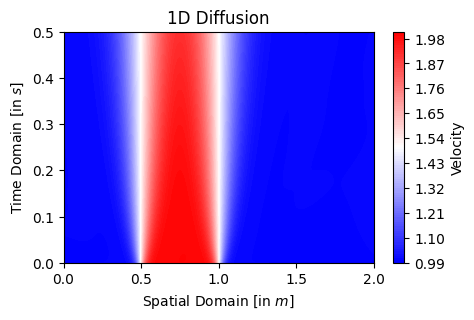

In [12]:
from matplotlib.colors import ListedColormap

# Create a grid for full 2D visualization
x_grid = np.linspace(0, x_max, nx)
t_grid = np.linspace(0, t_end, nt)
X_grid, T_grid  = np.meshgrid(x_grid, t_grid)
grid_points     = np.column_stack([X_grid.ravel(), T_grid.ravel()])

# Predict u, v, p on the grid  
U_pinns = model.predict(grid_points).reshape(X_grid.shape)

# Plot contour
plt.figure(figsize=FIG_SIZE)
contour = plt.contourf(X_grid, T_grid, U_pinns, levels=100, cmap="bwr")
plt.colorbar(contour, label='Velocity')

plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')
plt.title('1D Diffusion')
# plt.axis('equal')


In [ ]:
# plt.figure(figsize=FIG_SIZE)
# plt.plot(X_grid[0, :], U_pinns[0, :], "r", label="t = 0 s [PINNs]")
# plt.plot(X_grid[-1, :], U_pinns[-1, :], "k", label=f"t = {t_end} s [PINNs]")
# plt.title("1D Diffusion")
# plt.xlabel("Spatial Domain [in $m$]")
# plt.ylabel("Velocity [in $m/s$]")
# plt.axis(FIG_AXIS)
# plt.grid("on")
# plt.legend()


## Finite Difference Method (FDM)

$$
\begin{aligned}
\frac{ \partial u}{\partial t} &= \nu \frac{ \partial^2 u}{\partial x^2} \\[10pt]
\frac{u_i^{n+1} - u_i^n}{\Delta t} &= \nu \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2} \\[10pt]
u_i^{n+1} - u_i^n &= \frac{\nu \Delta t}{\Delta x^2} \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right) \\[10pt]
u_i^{n+1} &= u_i^n + \frac{\nu \Delta t}{\Delta x^2} \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right)
\end{aligned}
$$

In [13]:
# FDM for diffusion problem
def fdm_diffusion(nu, x_max, t_end, nx, nt, u_initial):

    # space discretization
    dx  = x_max / (nx - 1)
    dt  = t_end / (nt - 1)

    # time discretization
    sigma       = dt * nu / dx**2
    sigma_max   = 0.4

    # stability check
    if (sigma > sigma_max):
        raise ValueError(f"Sigma is {sigma:.3f} which is greater than {sigma_max}. Solution will be unstable. Increase value of `nt` or decrease `nx`.")

    # FDM explicit scheme
    U       = np.zeros((nt, nx))
    U[0, :] = u_initial.copy() # initial condition
    U[:, 0] = 1 # left boundary condition
    U[:, -1]= 1 # right boundary condition

    # iterate through time
    # -> FTCS Scheme [Forward in Time and Central in Space]
    for n in range(1, nt):
        U[n, 1:-1] = U[n-1, 1:-1] + nu*dt/dx**2 * ( U[n-1, 2:] - 2*U[n-1, 1:-1] + U[n-1, 0:-2])
            
    return U


In [15]:
# FDM
sigma   = dt * nu / dx**2
U_fdm   = fdm_diffusion(nu, x_max, t_end, nx, nt, u_init)

# print
print(f"nu = {nu} \t sigma = {sigma} \t dx = {dx:.3f} m \t dt = {dt*1e3:.3f} ms \t u_max_end={max(U_fdm[-1, :]):.3f}")


nu = 0.02 	 sigma = 0.4 	 dx = 0.010 m 	 dt = 2.000 ms 	 u_max_end=1.913


### FDM vs PINNs Solution Comparison

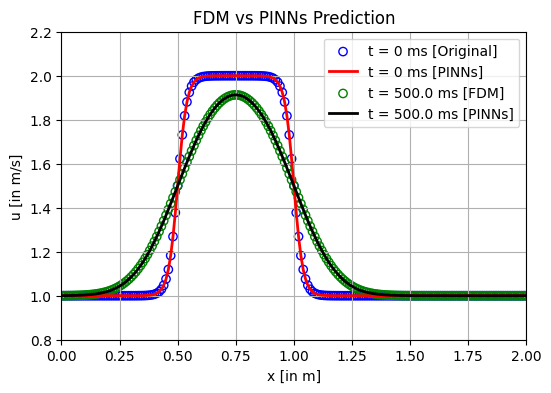

In [16]:
# plotting
plt.figure(figsize=(6, 4))
plt.title("FDM vs PINNs Prediction")

plt.scatter(x_arr, u_init, facecolors='none', edgecolors='blue', label=f"t = 0 ms [Original]")
plt.plot(X_grid[0, :], U_pinns[0, :], "r", lw=2, label="t = 0 ms [PINNs]")

plt.scatter(x_arr, U_fdm[-1, :], facecolors='none', edgecolors='g', label=f"t = {t_end*1e3} ms [FDM]")
plt.plot(X_grid[-1, :], U_pinns[-1, :], "k", lw=2, label=f"t = {t_end*1e3} ms [PINNs]")

plt.axis(FIG_AXIS)
plt.xlabel("x [in m]")
plt.ylabel("u [in m/s]")
plt.grid("on")
plt.legend()


### Aboslute Relative Error

$$ u_{error} = \frac{ | u_{fdm} - u_{pinns} | }{ | u_{max} | } $$


Text(0.5, 1.0, 'Absolute Relative Error Contour')

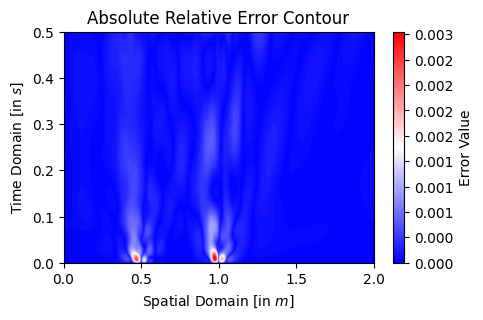

In [17]:
# Compute error 
u_max   = max(u_init)
U_error = abs(U_fdm - U_pinns) / u_max

# Plot Error Contour
plt.figure(figsize=FIG_SIZE)
contour = plt.contourf(X_grid, T_grid, U_error, levels=100, cmap="bwr")
plt.colorbar(contour, label='Error Value', format='%.3f')

plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')
plt.title('Absolute Relative Error Contour')


## Conclusion

As can be seen from the line plot and contoru plot, the match between PINNs prediction and FDM solution is excellent and the maximum absolute error of less than 1% is achieved.